In [31]:
import pandas as pd 

file_path = "baysor_merfish_gut/data_analysis/baysor_membrane_prior/segmentation/segmentation.csv"
molecules_df = pd.read_csv(file_path)

#
print(molecules_df.head())
print(molecules_df.shape)
print(molecules_df.columns)

    mol_id     x_raw     y_raw  z_raw  gene  area  brightness  \
0  3048145 -2935.386 -1218.580    2.5  Maoa     4    2.021306   
1  3048147 -2933.229 -1147.614    2.5  Maoa     4    1.828640   
2  3048148 -2930.104 -1154.062    2.5  Maoa     5    2.001268   
3  3048149 -2929.339 -1153.784    2.5  Maoa     7    1.960428   
4  3048153 -2913.718 -1270.474    2.5  Maoa     6    1.937280   

   total_magnitude  qc_score       x  ...  membrane_prior_3d  molecule_id  \
0         420.1126  0.954363  1705.0  ...                  0            1   
1         269.5874  0.908246  1725.0  ...                  0            2   
2         501.4615  0.977219  1753.0  ...                  0            3   
3         639.0364  0.991316  1760.0  ...                  0            4   
4         519.3154  0.983210  1904.0  ...               5493            5   

   prior_segmentation  confidence  compartment  nuclei_probs  cell  \
0                   0     0.89567      Unknown           1.0    84   
1     

In [37]:
len(molecules_df[molecules_df['nuclei_probs']>-1])

819665

In [40]:
def format_merfish(molecules_df: pd.DataFrame, nuclei_thresh: float = 0.9) -> pd.DataFrame:
    """
    Format raw MERFISH molecules DataFrame.

    Keeps only relevant columns, renames them, and derives 'overlaps_nucleus'.

    Parameters
    ----------
    molecules_df : pd.DataFrame
        Raw molecules DataFrame from MERFISH CSV
    nuclei_thresh : float, optional
        Threshold for nuclei_probs to assign overlaps_nucleus = 1, by default 0.9

    Returns
    -------
    pd.DataFrame
        Formatted molecules DataFrame with columns:
        transcript_id, feature_name, cell_id, x, y, z, is_noise, nuclei_probs, overlaps_nucleus
    """
    # List of required columns
    required_cols = [
        "mol_id",
        "gene",
        "cell",
        "x",
        "y",
        "z",
        "is_noise",
        "nuclei_probs",
        "qc_score"
    ]

    # Check if all columns exist
    missing_cols = [c for c in required_cols if c not in molecules_df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in molecules_df: {missing_cols}")

    # Select only required columns
    df = molecules_df[required_cols].copy()

    # Rename columns
    df.rename(
        columns={
            "mol_id": "transcript_id",
            "gene": "feature_name",
            "cell": "cell_id",
            "qc_score": "qv"
        },
        inplace=True
    )

    # Derive overlaps_nucleus: 1 if nuclei_probs > threshold, else 0
    df["overlaps_nucleus"] = (df["nuclei_probs"] > nuclei_thresh).astype(int)

    return df

In [9]:
formatted_df = format_merfish(molecules_df)
formatted_df.heaad()

,x,y,z,feature_name,cell_id,codeword_index,transcript_id,overlaps_nucleus,nucleus_distance,qv,fov_name
1,202.231186,1421.553955,16.527092,THBS2,UNASSIGNED,46,281582350895222,0,327.802612,40.000000,C2
2,60.755959,1427.187744,16.859751,CXCR4,UNASSIGNED,379,281582350896236,0,359.865814,38.001629,C2
3,116.347923,1415.833618,16.661528,CXCR4,UNASSIGNED,379,281582350896244,0,349.481201,40.000000,C2
4,195.983978,1445.074829,16.494038,EGFL7,UNASSIGNED,223,281582350896355,0,304.836700,40.000000,C2
5,64.536530,1440.388916,16.667513,PROX1,UNASSIGNED,233,281582350897810,0,346.369476,40.000000,C2


In [42]:
formatted_df.to_parquet("mouse_gut_filtered_df.parquet", engine="pyarrow", index=False)

In [43]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# Starting nucleus df
nuc_df = formatted_df[
    (formatted_df["cell_id"] != "UNASSIGNED") &
    (formatted_df["overlaps_nucleus"] == 1)
].copy()

# Count transcripts per nucleus
nuc_counts = nuc_df.groupby("cell_id").size()

# Compute thresholds
low_thres = np.percentile(nuc_counts, 0)
high_thres = np.percentile(nuc_counts, 100)

print("Transcript count thresholds:", low_thres, high_thres)

# Keep only "confident" nuclei
good_nuc_ids = nuc_counts[(nuc_counts >= low_thres) & (nuc_counts <= high_thres)].index
nuc_df_confident = nuc_df[nuc_df["cell_id"].isin(good_nuc_ids)].copy()

print("Number of confident nuclei:", len(good_nuc_ids))

Transcript count thresholds: 1.0 7586.0
Number of confident nuclei: 7538


In [44]:
def compute_npmi_presence_absence(
    df_subset,
    group_key="cell_id",
    min_occurrences_per_context=2
):
    """
    Compute PMI/NPMI using presence/absence of genes at the cell or nucleus level,
    with robustness control by requiring each gene to occur at least N times
    within a context (cell or nucleus) before being considered "present".

    Returns
    -------
    long_df : DataFrame
        Columns:
            gene_i, gene_j, P_i, P_j, P_ij,
            P_i_given_j, P_j_given_i, PMI, NPMI
    """

    # 0. Subset to necessary columns
    df = df_subset[[group_key, "feature_name"]].copy()

    # ----------------------------------------------------------------------
    # Filter by minimum occurrences per context
    # ----------------------------------------------------------------------
    # Count gene occurrences within each cell/nucleus
    counts = (
        df.groupby([group_key, "feature_name"])
        .size()
        .rename("gene_count")
        .reset_index()
    )

    # Keep only those gene occurrences with enough counts
    df_filtered = counts[counts["gene_count"] >= min_occurrences_per_context].copy()

    if df_filtered.empty:
        raise ValueError(
            f"No genes pass min_occurrences_per_context={min_occurrences_per_context}."
        )

    # For presence/absence, set value = 1 for all retained (context, gene) pairs
    df_filtered["value"] = 1

    # ----------------------------------------------------------------------
    # Pivot to contexts × genes matrix (presence/absence)
    # ----------------------------------------------------------------------
    M = df_filtered.pivot_table(
        index=group_key,
        columns="feature_name",
        values="value",
        aggfunc="max",
        fill_value=0
    )

    contexts = M.index.to_numpy()
    genes = M.columns.to_numpy()
    C = M.shape[0]

    # ----------------------------------------------------------------------
    # Probabilities P(i), P(i,j)
    # ----------------------------------------------------------------------
    counts_i = M.sum(axis=0).to_numpy()
    P_i = counts_i / C

    co_matrix = (M.T @ M).to_numpy()
    P_ij = co_matrix / C

    # ----------------------------------------------------------------------
    # Conditional probabilities
    # ----------------------------------------------------------------------
    P_i_col = P_i[:, None]
    P_j_row = P_i[None, :]

    with np.errstate(divide="ignore", invalid="ignore"):
        P_i_given_j = np.where(P_j_row > 0, P_ij / P_j_row, np.nan)
        P_j_given_i = np.where(P_i_col > 0, P_ij / P_i_col, np.nan)

    # ----------------------------------------------------------------------
    # PMI & NPMI
    # ----------------------------------------------------------------------
    PMI = np.full_like(P_ij, np.nan)
    NPMI = np.full_like(P_ij, np.nan)

    denom = P_i_col * P_j_row
    valid = (P_ij > 0) & (denom > 0)

    with np.errstate(divide="ignore", invalid="ignore"):
        PMI[valid] = np.log(P_ij[valid] / denom[valid])
        NPMI[valid] = PMI[valid] / (-np.log(P_ij[valid]))

    # ----------------------------------------------------------------------
    # Convert to long format
    # ----------------------------------------------------------------------
    G = len(genes)
    long_df = pd.DataFrame({
        "gene_i": np.repeat(genes, G),
        "gene_j": np.tile(genes, G),
        "P_i": np.repeat(P_i, G),
        "P_j": np.tile(P_i, G),
        "P_ij": P_ij.ravel(),
        "P_i_given_j": P_i_given_j.ravel(),
        "P_j_given_i": P_j_given_i.ravel(),
        "PMI": PMI.ravel(),
        "NPMI": NPMI.ravel(),
    })

    return long_df

In [45]:
nucleus_npmi_long = compute_npmi_presence_absence(nuc_df_confident, group_key="cell_id", min_occurrences_per_context=2)

In [46]:
print("PMI: min =", np.nanmin(nucleus_npmi_long.PMI), "max =", np.nanmax(nucleus_npmi_long.PMI))
print("NPMI: min =", np.nanmin(nucleus_npmi_long.NPMI), "max =", np.nanmax(nucleus_npmi_long.NPMI))

PMI: min = -4.572002041019285 max = 8.880585523102495
NPMI: min = -0.5148311481405591 max = 1.0000000000000002


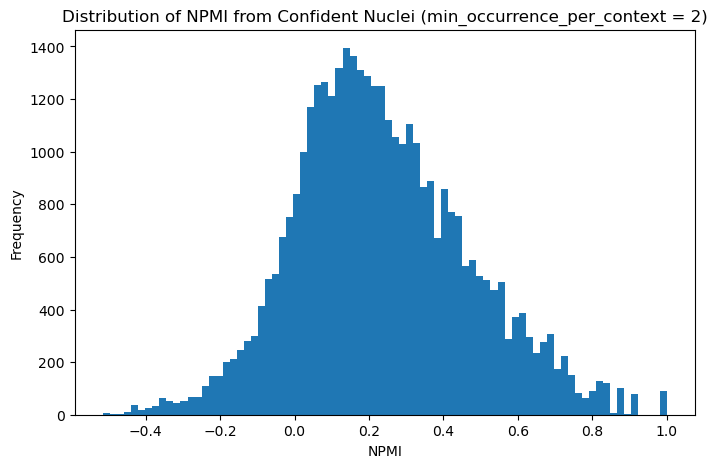

Top 10 highest NPMI gene pairs:
       gene_i   gene_j       P_i       P_j      P_ij  P_i_given_j  P_j_given_i  \
2676   Adrb3     Ghsr  0.000139  0.000139  0.000139          1.0          1.0   
2704   Adrb3    Htr5b  0.000139  0.000139  0.000139          1.0          1.0   
2705   Adrb3     Htr6  0.000139  0.000139  0.000139          1.0          1.0   
2714   Adrb3      Il5  0.000139  0.000139  0.000139          1.0          1.0   
2716   Adrb3      Il9  0.000139  0.000139  0.000139          1.0          1.0   
2732   Adrb3    Lpar4  0.000139  0.000139  0.000139          1.0          1.0   
2771   Adrb3  Ptprcap  0.000139  0.000139  0.000139          1.0          1.0   
2801   Adrb3    Taar5  0.000139  0.000139  0.000139          1.0          1.0   
2806   Adrb3   Taar8a  0.000139  0.000139  0.000139          1.0          1.0   
15636   Ghsr    Adrb3  0.000139  0.000139  0.000139          1.0          1.0   

            PMI  NPMI  
2676   8.880586   1.0  
2704   8.880586   1.0  
270

In [47]:
# exclude self-pairs
nucleus_npmi_pairs = nucleus_npmi_long[
    nucleus_npmi_long["gene_i"] != nucleus_npmi_long["gene_j"]
].copy()

plt.figure(figsize=(8,5))
plt.hist(nucleus_npmi_pairs["NPMI"].dropna(), bins=80)
plt.xlabel("NPMI")
plt.ylabel("Frequency")
plt.title("Distribution of NPMI from Confident Nuclei (min_occurrence_per_context = 2)")
plt.show()

# Top 10 positive
top10 = nucleus_npmi_pairs.nlargest(10, "NPMI")
print("Top 10 highest NPMI gene pairs:\n", top10)

# Bottom 10
bottom10 = nucleus_npmi_pairs.nsmallest(10, "NPMI")
print("Bottom 10 lowest NPMI gene pairs:\n", bottom10)

In [48]:
nucleus_npmi_long.to_csv("mouse_gut_nucleus_npmi_long_min_count_2.csv", index=False)